In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# memuat dataset
customer = pd.read_csv('data/olist_customers_dataset.csv')
order = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')

print ("data successfully loaded")
print (order.head())

data successfully loaded
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 1

In [3]:
# 1. Menggabungkan tabel orders dan order_items untuk mendapatkan nilai harga (price) per order_id
df_merged = pd.merge(order_items, order, on='order_id', how='inner')

# 2. Menggabungkan dengan tabel customers agar kita bisa melacak berdasarkan customer_unique_id
# (Menggunakan customer_unique_id agar satu orang yang belanja berkali-kali terhitung sebagai 1 pelanggan yang sama)
df_merged = pd.merge(df_merged, customer[['customer_id', 'customer_unique_id']], on='customer_id', how='inner')

# Mengubah kolom tanggal menjadi format datetime
df_merged['order_purchase_timestamp'] = pd.to_datetime(df_merged['order_purchase_timestamp'])

# Menentukan tanggal acuan (snapshot date) yaitu 1 hari setelah tanggal transaksi paling akhir di data
snapshot_date = df_merged['order_purchase_timestamp'].max() + dt.timedelta(days=1)

# 3. Menghitung nilai Recency, Frequency, dan Monetary per pelanggan
rfm_table = df_merged.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency: hari sejak transaksi terakhir
    'order_id': 'nunique', # Frequency: berapa kali belanja
    'price': 'sum' # Monetary: total uang yang dibelanjakan
})

# Mengubah nama kolom agar rapi
rfm_table.rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'price': 'Monetary'
}, inplace=True)

# Menampilkan 5 data teratas hasil perhitungan RFM
print("Tabel RFM Berhasil Dibuat:")
print(rfm_table.head())

Tabel RFM Berhasil Dibuat:
                                  Recency  Frequency  Monetary
customer_unique_id                                            
0000366f3b9a7992bf8c76cfdf3221e2      116          1    129.90
0000b849f77a49e4a4ce2b2a4ca5be3f      119          1     18.90
0000f46a3911fa3c0805444483337064      542          1     69.00
0000f6ccb0745a6a4b88665a16c9f078      326          1     25.99
0004aac84e0df4da2b147fca70cf8255      293          1    180.00


In [4]:
# 1. Menghitung skor R, F, dan M (Skala 1-4 menggunakan Quartile)
# Recency: Harinya semakin kecil = semakin baik (skor 4)
rfm_table['R_Score'] = pd.qcut(rfm_table['Recency'], 4, labels=[4, 3, 2, 1])

# Monetary: Belanjanya semakin besar = semakin baik (skor 4)
rfm_table['M_Score'] = pd.qcut(rfm_table['Monetary'], 4, labels=[1, 2, 3, 4])

# Frequency: Karena di e-commerce banyak yang hanya belanja 1 kali, kita gunakan rank() agar tidak error
rfm_table['F_Score'] = pd.qcut(rfm_table['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])

# 2. Menggabungkan skor menjadi satu kode profil (Contoh: "444" adalah pelanggan VIP)
rfm_table['RFM_Segment'] = rfm_table['R_Score'].astype(str) + rfm_table['F_Score'].astype(str) + rfm_table['M_Score'].astype(str)

# 3. Menghitung total skor untuk mempermudah penamaan segmen nantinya (Total skor 3 sampai 12)
rfm_table['RFM_Score'] = rfm_table[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

print("Skoring RFM Berhasil Dibuat!")
print(rfm_table.head())

Skoring RFM Berhasil Dibuat!
                                  Recency  Frequency  Monetary R_Score  \
customer_unique_id                                                       
0000366f3b9a7992bf8c76cfdf3221e2      116          1    129.90       4   
0000b849f77a49e4a4ce2b2a4ca5be3f      119          1     18.90       4   
0000f46a3911fa3c0805444483337064      542          1     69.00       1   
0000f6ccb0745a6a4b88665a16c9f078      326          1     25.99       2   
0004aac84e0df4da2b147fca70cf8255      293          1    180.00       2   

                                 M_Score F_Score RFM_Segment  RFM_Score  
customer_unique_id                                                       
0000366f3b9a7992bf8c76cfdf3221e2       3       1         413          8  
0000b849f77a49e4a4ce2b2a4ca5be3f       1       1         411          6  
0000f46a3911fa3c0805444483337064       2       1         112          4  
0000f6ccb0745a6a4b88665a16c9f078       1       1         211          4  
0004aac8

Jumlah Pelanggan per Segmen:
Customer_Segment
Potential Loyalist    32836
Loyal Customers       31792
Champions (VIP)       15287
At Risk               13966
Lost Customers         1539
Name: count, dtype: int64


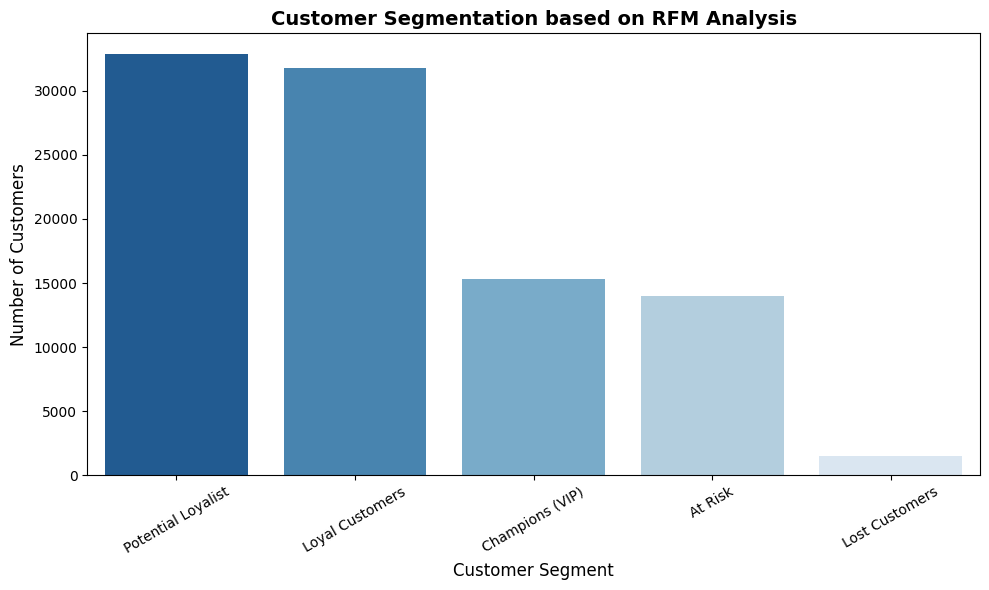

In [7]:
# 1. Membuat fungsi untuk mengelompokkan pelanggan berdasarkan Total Skor RFM
def rfm_customer_segment(df):
    if df['RFM_Score'] >= 10:
        return 'Champions (VIP)'
    elif df['RFM_Score'] >= 8:
        return 'Loyal Customers'
    elif df['RFM_Score'] >= 6:
        return 'Potential Loyalist'
    elif df['RFM_Score'] >= 4:
        return 'At Risk'
    else:
        return 'Lost Customers'

# Menerapkan fungsi ke tabel RFM
rfm_table['Customer_Segment'] = rfm_table.apply(rfm_customer_segment, axis=1)

# 2. Menghitung jumlah pelanggan di setiap segmen
segment_counts = rfm_table['Customer_Segment'].value_counts()
print("Jumlah Pelanggan per Segmen:")
print(segment_counts)

# 3. Membuat visualisasi sederhana (Bar Plot)
plt.figure(figsize=(10, 6))
sns.barplot(x=segment_counts.index, y=segment_counts.values, hue=segment_counts.index, palette='Blues_r', legend=False)
# sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='Blues_r')
plt.title('Customer Segmentation based on RFM Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.savefig('rfm_segmentation_chart.png', dpi=300, bbox_inches='tight')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()